# 🍷 Wine Quality Prediction
## Cases D Machine Learning Project

This notebook compares six feature-engineering cases for regression and classification.

## 1. Introduction
The objective is to predict wine quality from physicochemical measurements. We compare regression and classification approaches and investigate the effect of converting selected continuous variables into categories.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import classification_report


from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler



In [17]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## 2. Load Dataset

In [18]:
wine_df = pd.read_csv("WineQT.csv")
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 3. Initial Exploration

In [19]:
wine_df.info()
wine_df.describe()
wine_df.isnull().sum()
wine_df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


np.int64(0)

## 4. Exploratory Data Analysis

In [20]:
wine_df = wine_df.drop(columns='Id')

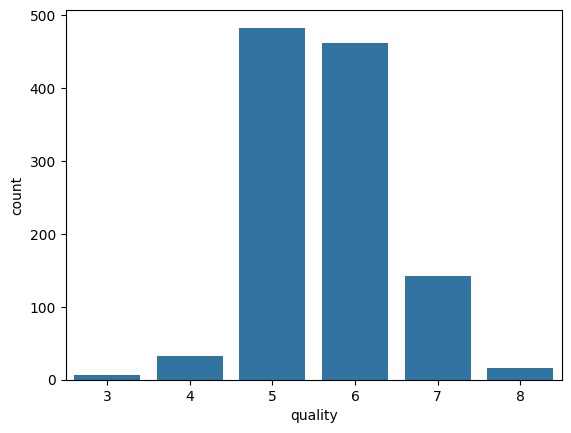

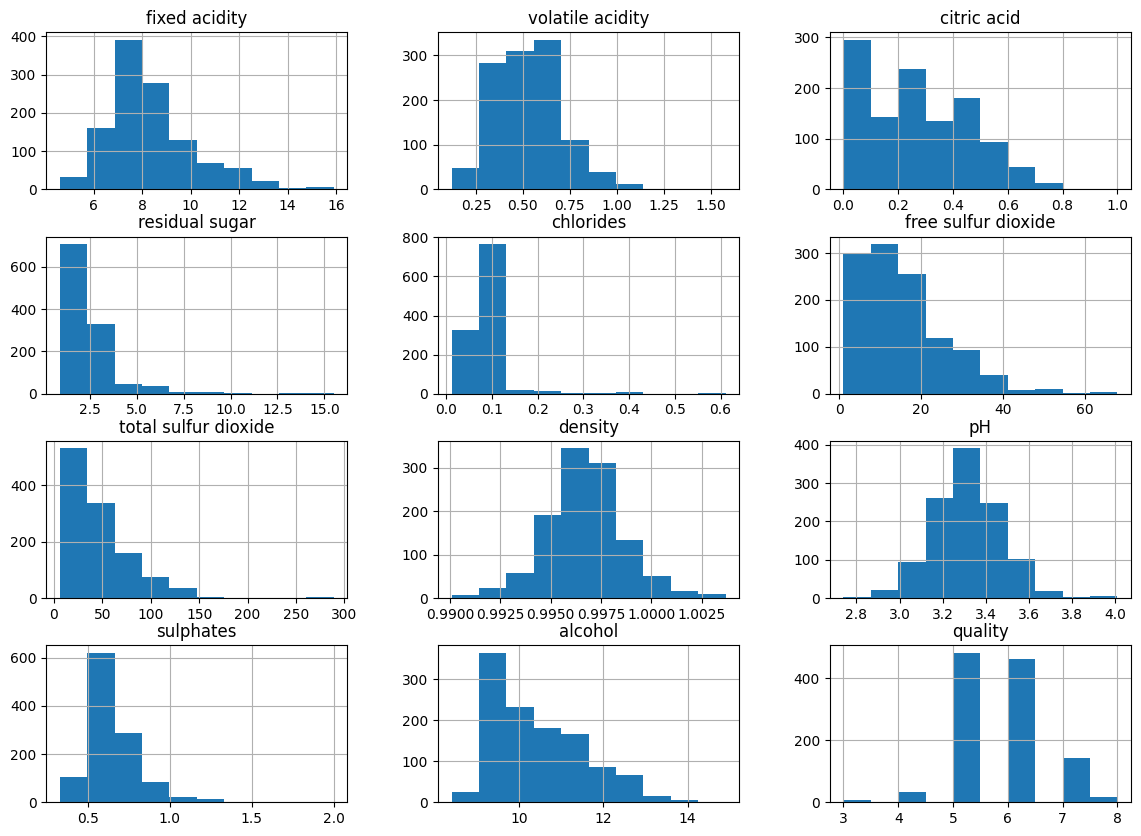

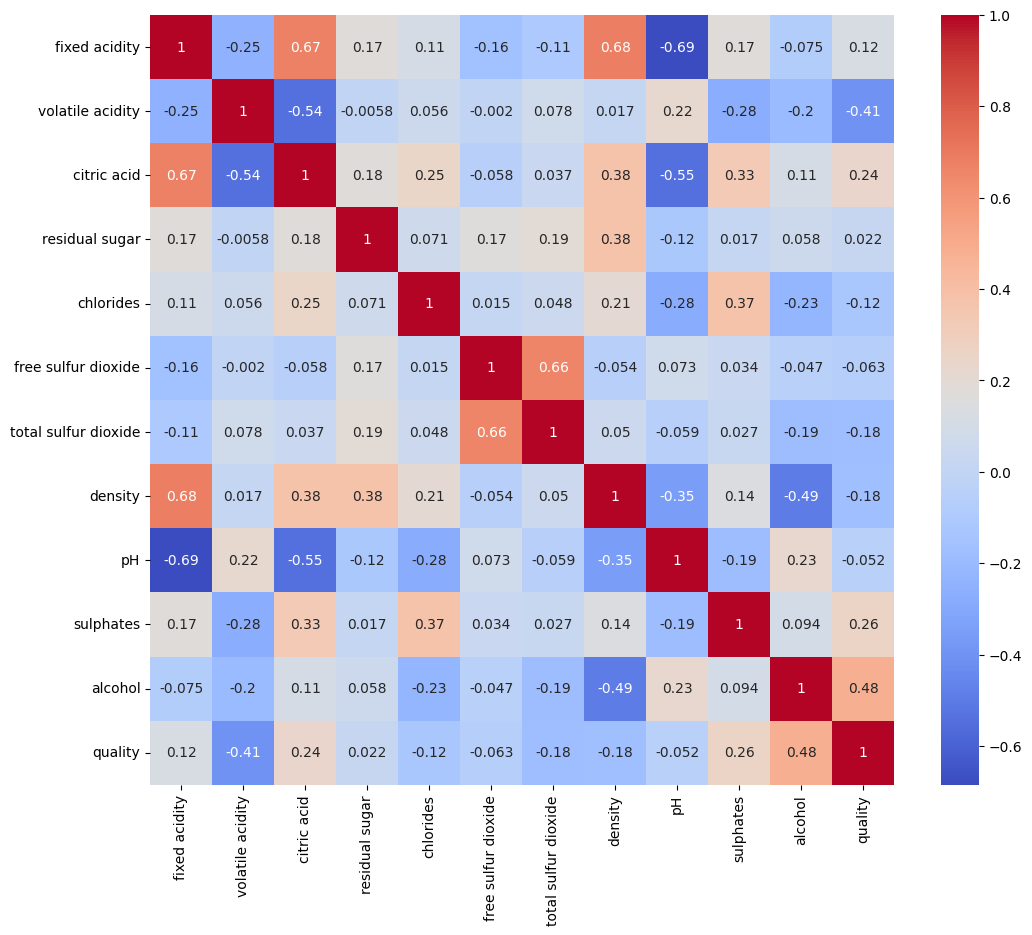

In [21]:
sns.countplot(data=wine_df,x='quality')
plt.show()

wine_df.hist(figsize=(14,10))
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(wine_df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

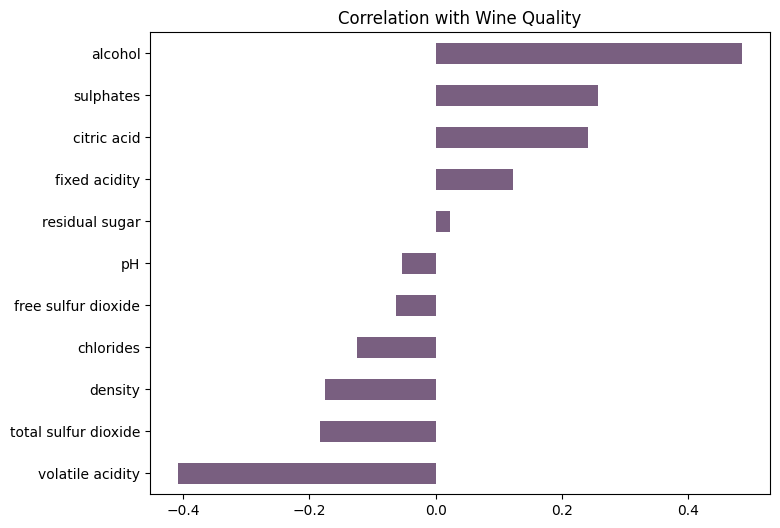

In [98]:
quality_corr = (
    wine_df
    .corr(numeric_only=True)["quality"]
    .drop("quality")
    .sort_values()
)

plt.figure(figsize=(8,6))

quality_corr.plot(kind="barh", color=["#795F80"])

plt.title("Correlation with Wine Quality")

plt.show()

## 5. Data Cleaning

In [62]:
#Id was dropped in before EDA
selected_features_df = wine_df
selected_features_df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 6. Feature Engineering
Create Cases 1–6 (baseline, pH categorical, pH+Residual Sugar categorical for both regression and classification).

In [63]:
case_11num = selected_features_df.copy()

### Imbalance adjustments

### Categorize pH

In [64]:
case_10num = selected_features_df.copy()

# Create the categorical variable
case_10num['pH_cat'] = pd.cut(
    case_10num['pH'],
    bins=[0, 3.2, 3.5, 10],
    labels=['HighAcidity', 'Medium', 'LowAcidity']
)

# Initialize the encoder (keep all categories)
encoder_pH = OneHotEncoder(sparse_output=False)

# Encode the categorical feature
encoded_pH = encoder_pH.fit_transform(case_10num[['pH_cat']])

# Create a DataFrame with the encoded columns
encoded_pH_df = pd.DataFrame(
    encoded_pH,
    columns=encoder_pH.get_feature_names_out(['pH_cat']),
    index=case_10num.index
)

# Drop the original columns and concatenate the encoded ones
case_10num  = pd.concat(
    [case_10num .drop(columns=['pH', 'pH_cat']), encoded_pH_df],
    axis=1
)
case_10num.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,sulphates,alcohol,quality,pH_cat_HighAcidity,pH_cat_LowAcidity,pH_cat_Medium
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,0.56,9.4,5,0.0,1.0,0.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,0.68,9.8,5,1.0,0.0,0.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,0.65,9.8,5,0.0,0.0,1.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,0.58,9.8,6,1.0,0.0,0.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,0.56,9.4,5,0.0,1.0,0.0


### Categorize ResidualSugar

In [65]:
case_9num = case_10num.copy()

# Create the categorical variable
case_9num['ResidualSugar_cat'] = pd.cut(
    case_9num['residual sugar'],
    bins=[0, 4, 12, 100],
    labels=['Dry', 'OffDry', 'Sweet']
)

# Initialize the encoder (keep all categories)
encoder_sugar = OneHotEncoder(sparse_output=False)

# Encode the categorical feature
encoded_sugar = encoder_sugar.fit_transform(case_9num[['ResidualSugar_cat']])

# Create a DataFrame with the encoded columns
encoded_sugar_df = pd.DataFrame(
    encoded_sugar,
    columns=encoder_sugar.get_feature_names_out(['ResidualSugar_cat']),
    index=case_9num.index
)

# Drop the original columns and concatenate the encoded ones
case_9num = pd.concat(
    [case_9num.drop(columns=['residual sugar', 'ResidualSugar_cat']), encoded_sugar_df],
    axis=1
)
case_9num.head(5)

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,density,sulphates,alcohol,quality,pH_cat_HighAcidity,pH_cat_LowAcidity,pH_cat_Medium,ResidualSugar_cat_Dry,ResidualSugar_cat_OffDry,ResidualSugar_cat_Sweet
0,7.4,0.70,0.00,0.076,11.0,34.0,0.9978,0.56,9.4,5,0.0,1.0,0.0,1.0,0.0,0.0
1,7.8,0.88,0.00,0.098,25.0,67.0,0.9968,0.68,9.8,5,1.0,0.0,0.0,1.0,0.0,0.0
2,7.8,0.76,0.04,0.092,15.0,54.0,0.9970,0.65,9.8,5,0.0,0.0,1.0,1.0,0.0,0.0
3,11.2,0.28,0.56,0.075,17.0,60.0,0.9980,0.58,9.8,6,1.0,0.0,0.0,1.0,0.0,0.0
4,7.4,0.70,0.00,0.076,11.0,34.0,0.9978,0.56,9.4,5,0.0,1.0,0.0,1.0,0.0,0.0


## 8. Modeling

**_Preparation:_** <br>
Implement reusable functions to evaluate regression and classification models across all cases.

**_Modeling_**<br>
All cases (regression and classification will follow the steps:
1. Split each case into features and target (x-y)
2. Split into train and test
3. Scale (where appropriate - with algorithms that are sensitive to feature scale (e.g., KNN, Logistic Regression.)
4. Evaluate Model
   - Regression
   -Classification
6. Store results in comparison tables 



### **_Preparation_**

In [66]:
def regression_metrics(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    return {
        'MAE':mean_absolute_error(y_test,pred),
        'RMSE':mean_squared_error(y_test,pred),
        'R2':r2_score(y_test,pred)
    }

def classification_metrics(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    print("Predicted classes:", np.unique(pred))


    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        )
    }

### **_Modeling_**

#### Case 6 - Oversampling

In [67]:
#1. Split each case into features and target (x-y)
features_case_6 = case_9num.drop(columns='quality')
target_case_6 = case_9num['quality'].astype(int)

#2. Split into train and test

X_train, X_test, y_train, y_test = train_test_split(
    features_case_6,
    target_case_6,
    test_size=0.20,
    random_state=17,
    stratify=target_case_6
)

In [68]:
# INBALANCE PROCESSING
# Apply oversampling ONLY to the training data

ros = RandomOverSampler(random_state=17)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_over.value_counts())

quality
5    386
6    370
7    114
4     26
8     13
3      5
Name: count, dtype: int64
quality
5    386
7    386
6    386
4    386
8    386
3    386
Name: count, dtype: int64


In [69]:
#3. Scale (where appropriate)
scaler = StandardScaler()

# Replace input with over, under or SMOTE
X_train_over_scaled = scaler.fit_transform(X_train_over)

X_test_scaled = scaler.transform(X_test)

In [70]:
#4. Evaluate Model
results_classification_case6 = []

# -----------------------------
# Logistic Regression
# -----------------------------
#Although the target is multiclass, Scikit-learn automatically performs multinomial logistic regression.
log_model = LogisticRegression(
    max_iter=1000,
    random_state=17
)

metrics = classification_metrics(
    log_model,
    X_train_over_scaled,
    X_test_scaled,
    y_train_over,
    y_test
)

metrics["Case"] = "Case 6-Oversampling"
metrics["Model"] = "Logistic Regression"

results_classification_case6.append(metrics)

# -----------------------------
# K-Nearest Neighbours
# -----------------------------
for k in [1,3,5,10,20,50]:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    metrics = classification_metrics(
        knn,
        X_train_over_scaled,
        X_test_scaled,
        y_train_over,
        y_test
    )

    metrics["Case"] = "Case 6-Oversampling"
    metrics["Model"] = f"KNN (k={k})"

    results_classification_case6.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------
tree = DecisionTreeClassifier(
    random_state=17
)

metrics = classification_metrics(
    tree,
    X_train_over,
    X_test,
    y_train_over,
    y_test
)

metrics["Case"] = "Case 6-Oversampling"
metrics["Model"] = "Decision Tree"

results_classification_case6.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=17
)

metrics = classification_metrics(
    forest,
    X_train_over,
    X_test,
    y_train_over,
    y_test
)

metrics["Case"] = "Case 6-Oversampling"
metrics["Model"] = "Random Forest"

results_classification_case6.append(metrics)


Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]


In [71]:
#5. Store results in comparison tables
results_case6_over = pd.DataFrame(results_classification_case6)

results_case6_over = results_case6_over[
    [
        "Case",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

results_case6_over = results_case6_over.sort_values(
    by="Accuracy",
    ascending=False
)

results_case6_over.reset_index(drop=True, inplace=True)

results_case6_over


,Case,Model,Accuracy,Precision,Recall,F1
0,Case 6-Oversampling,Random Forest,0.633188,0.627759,0.633188,0.624294
1,Case 6-Oversampling,Decision Tree,0.576419,0.595936,0.576419,0.580979
2,Case 6-Oversampling,KNN (k=1),0.576419,0.570571,0.576419,0.571656
3,Case 6-Oversampling,KNN (k=3),0.510917,0.529492,0.510917,0.512421
4,Case 6-Oversampling,KNN (k=5),0.497817,0.542834,0.497817,0.509874
5,Case 6-Oversampling,KNN (k=10),0.432314,0.526540,0.432314,0.459389
6,Case 6-Oversampling,KNN (k=50),0.358079,0.556461,0.358079,0.425208
7,Case 6-Oversampling,Logistic Regression,0.353712,0.490707,0.353712,0.399898
8,Case 6-Oversampling,KNN (k=20),0.340611,0.495692,0.340611,0.394176


#### Case 6 - Undersampling

In [72]:
#1. Split each case into features and target (x-y)
features_case_6 = case_9num.drop(columns='quality')
target_case_6 = case_9num['quality'].astype(int)

#2. Split into train and test

X_train, X_test, y_train, y_test = train_test_split(
    features_case_6,
    target_case_6,
    test_size=0.20,
    random_state=17,
    stratify=target_case_6
)

In [73]:
# INBALANCE PROCESSING

rus = RandomUnderSampler(random_state=17)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(y_train_under.value_counts())

quality
3    5
4    5
5    5
6    5
7    5
8    5
Name: count, dtype: int64


In [74]:
#3. Scale (where appropriate)
scaler = StandardScaler()

# Replace input with over, under or SMOTE
X_train_under_scaled = scaler.fit_transform(X_train_under)

X_test_scaled = scaler.transform(X_test)

In [75]:
#4. Evaluate Model
results_classification_case6 = []

# -----------------------------
# Logistic Regression
# -----------------------------
#Although the target is multiclass, Scikit-learn automatically performs multinomial logistic regression.
log_model = LogisticRegression(
    max_iter=1000,
    random_state=17
)

metrics = classification_metrics(
    log_model,
    X_train_under_scaled,
    X_test_scaled,
    y_train_under,
    y_test
)

metrics["Case"] = "Case 6-Undersampling"
metrics["Model"] = "Logistic Regression"

results_classification_case6.append(metrics)

# -----------------------------
# K-Nearest Neighbours
# -----------------------------

candidate_k = [1, 3, 5, 10, 20, 50]
k_values = [k for k in candidate_k if k <= len(X_train_under) - 1]

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    metrics = classification_metrics(
        knn,
        X_train_under_scaled,
        X_test_scaled,
        y_train_under,
        y_test
    )

    metrics["Case"] = "Case 6-Undersampling"
    metrics["Model"] = f"KNN (k={k})"

    results_classification_case6.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------
tree = DecisionTreeClassifier(
    random_state=17
)

metrics = classification_metrics(
    tree,
    X_train_under,
    X_test,
    y_train_under,
    y_test
)

metrics["Case"] = "Case 6-Undersampling"
metrics["Model"] = "Decision Tree"

results_classification_case6.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=17
)

metrics = classification_metrics(
    forest,
    X_train_under,
    X_test,
    y_train_under,
    y_test
)

metrics["Case"] = "Case 6-Undersampling"
metrics["Model"] = "Random Forest"

results_classification_case6.append(metrics)

Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]


In [76]:
print(X_train_under.shape)
print(y_train_under.value_counts().sort_index())

max_k = len(X_train_under)

print(max_k)

(30, 15)
quality
3    5
4    5
5    5
6    5
7    5
8    5
Name: count, dtype: int64
30


In [77]:
#5. Store results in comparison tables
results_case6_under = pd.DataFrame(results_classification_case6)

results_case6_under = results_case6_under[
    [
        "Case",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

results_case6_under = results_case6_under.sort_values(
    by="Accuracy",
    ascending=False
)

results_case6_under.reset_index(drop=True, inplace=True)

results_case6_under

,Case,Model,Accuracy,Precision,Recall,F1
0,Case 6-Undersampling,Logistic Regression,0.323144,0.551481,0.323144,0.370042
1,Case 6-Undersampling,Decision Tree,0.314410,0.512404,0.314410,0.377554
2,Case 6-Undersampling,Random Forest,0.310044,0.513853,0.310044,0.336035
3,Case 6-Undersampling,KNN (k=1),0.266376,0.551488,0.266376,0.325440
4,Case 6-Undersampling,KNN (k=3),0.248908,0.515754,0.248908,0.264596
5,Case 6-Undersampling,KNN (k=5),0.235808,0.405312,0.235808,0.267216
6,Case 6-Undersampling,KNN (k=10),0.227074,0.420589,0.227074,0.276728
7,Case 6-Undersampling,KNN (k=20),0.174672,0.424467,0.174672,0.218905


#### Case 6 - SMOTE

In [78]:
#1. Split each case into features and target (x-y)
features_case_6 = case_9num.drop(columns='quality')
target_case_6 = case_9num['quality'].astype(int)

#2. Split into train and test

X_train, X_test, y_train, y_test = train_test_split(
    features_case_6,
    target_case_6,
    test_size=0.20,
    random_state=17,
    stratify=target_case_6
)

In [79]:
# INBALANCE PROCESSING

min_class_size = y_train.value_counts().min()

k = min(5, min_class_size - 1)

print(f"Using k_neighbors = {k}")

smote = SMOTE(random_state=17, k_neighbors=k)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())




Using k_neighbors = 4
quality
5    386
7    386
6    386
4    386
8    386
3    386
Name: count, dtype: int64


In [80]:
print(y_train.value_counts().sort_index())

quality
3      5
4     26
5    386
6    370
7    114
8     13
Name: count, dtype: int64


In [81]:
#3. Scale (where appropriate)
scaler = StandardScaler()

# Replace input with over, under or SMOTE
X_train_smote_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [82]:
#4. Evaluate Model
results_classification_case6 = []

# -----------------------------
# Logistic Regression
# -----------------------------
#Although the target is multiclass, Scikit-learn automatically performs multinomial logistic regression.
log_model = LogisticRegression(
    max_iter=1000,
    random_state=17
)

metrics = classification_metrics(
    log_model,
    X_train_smote_scaled,
    X_test_scaled,
    y_train_smote,
    y_test
)

metrics["Case"] = "Case 6-SMOTE"
metrics["Model"] = "Logistic Regression"

results_classification_case6.append(metrics)

# -----------------------------
# K-Nearest Neighbours
# -----------------------------

candidate_k = [1, 3, 5, 10, 20, 50]
k_values = [k for k in candidate_k if k <= len(X_train_under) - 1]

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    metrics = classification_metrics(
        knn,
        X_train_smote_scaled,
        X_test_scaled,
        y_train_smote,
        y_test
    )

    metrics["Case"] = "Case 6-SMOTE"
    metrics["Model"] = f"KNN (k={k})"

    results_classification_case6.append(metrics)

# -----------------------------
# Decision Tree
# -----------------------------
tree = DecisionTreeClassifier(
    random_state=17
)

metrics = classification_metrics(
    tree,
    X_train_smote,
    X_test,
    y_train_smote,
    y_test
)

metrics["Case"] = "Case 6-SMOTE"
metrics["Model"] = "Decision Tree"

results_classification_case6.append(metrics)

# -----------------------------
# Random Forest
# -----------------------------
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=17
)

metrics = classification_metrics(
    forest,
    X_train_smote,
    X_test,
    y_train_smote,
    y_test
)

metrics["Case"] = "Case 6-SMOTE"
metrics["Model"] = "Random Forest"

results_classification_case6.append(metrics)

Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]
Predicted classes: [3 4 5 6 7 8]


In [83]:
#5. Store results in comparison tables
results_case6_smote = pd.DataFrame(results_classification_case6)

results_case6_smote = results_case6_smote[
    [
        "Case",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

results_case6_smote = results_case6_smote.sort_values(
    by="Accuracy",
    ascending=False
)

results_case6_smote.reset_index(drop=True, inplace=True)

results_case6_smote

,Case,Model,Accuracy,Precision,Recall,F1
0,Case 6-SMOTE,Random Forest,0.628821,0.636118,0.628821,0.627274
1,Case 6-SMOTE,KNN (k=1),0.541485,0.550579,0.541485,0.543471
2,Case 6-SMOTE,Decision Tree,0.484716,0.548710,0.484716,0.504114
3,Case 6-SMOTE,KNN (k=5),0.480349,0.535161,0.480349,0.498059
4,Case 6-SMOTE,KNN (k=3),0.467249,0.516910,0.467249,0.484292
5,Case 6-SMOTE,KNN (k=10),0.432314,0.524124,0.432314,0.466153
6,Case 6-SMOTE,KNN (k=20),0.384279,0.516821,0.384279,0.431775
7,Case 6-SMOTE,Logistic Regression,0.375546,0.529112,0.375546,0.424290


## 9. Results
Create comparison tables for regression (R², RMSE) and classification (Accuracy, Precision, Recall).

In [84]:
results_case6_over

,Case,Model,Accuracy,Precision,Recall,F1
0,Case 6-Oversampling,Random Forest,0.633188,0.627759,0.633188,0.624294
1,Case 6-Oversampling,Decision Tree,0.576419,0.595936,0.576419,0.580979
2,Case 6-Oversampling,KNN (k=1),0.576419,0.570571,0.576419,0.571656
3,Case 6-Oversampling,KNN (k=3),0.510917,0.529492,0.510917,0.512421
4,Case 6-Oversampling,KNN (k=5),0.497817,0.542834,0.497817,0.509874
5,Case 6-Oversampling,KNN (k=10),0.432314,0.526540,0.432314,0.459389
6,Case 6-Oversampling,KNN (k=50),0.358079,0.556461,0.358079,0.425208
7,Case 6-Oversampling,Logistic Regression,0.353712,0.490707,0.353712,0.399898
8,Case 6-Oversampling,KNN (k=20),0.340611,0.495692,0.340611,0.394176


In [85]:
results_all_classification = pd.concat(
    [
        results_case6_over,
        results_case6_under,
        results_case6_smote
    ],
    ignore_index=True
)

In [86]:
accuracy_table = results_all_classification.pivot(
    index="Model",
    columns="Case",
    values="Accuracy"
)

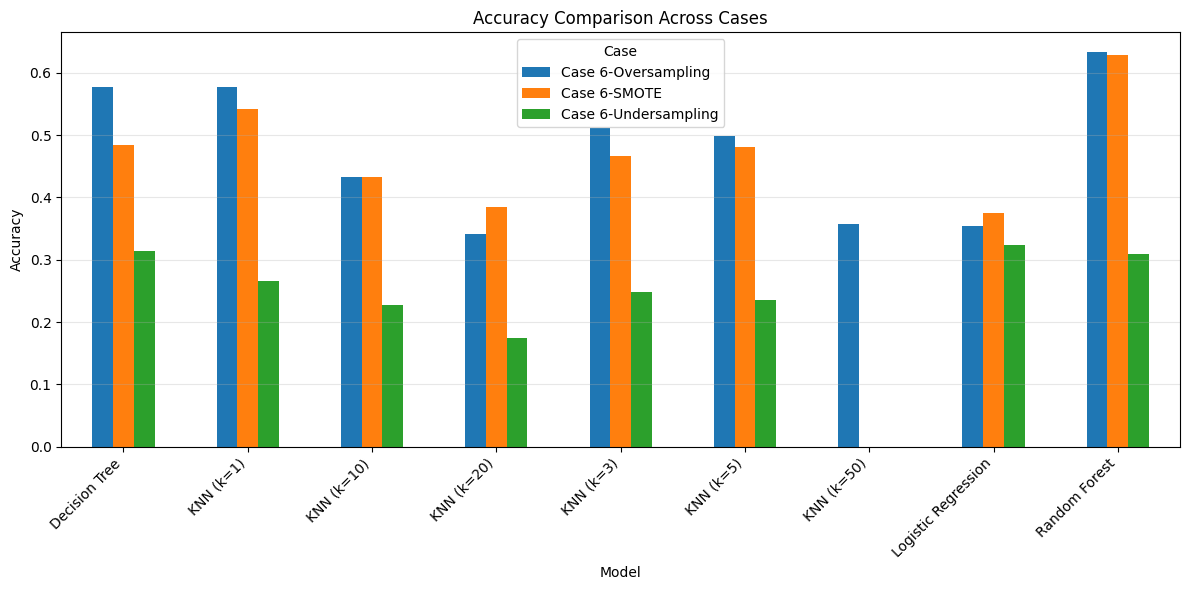

In [87]:
# Plot
accuracy_table.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Accuracy Comparison Across Cases")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

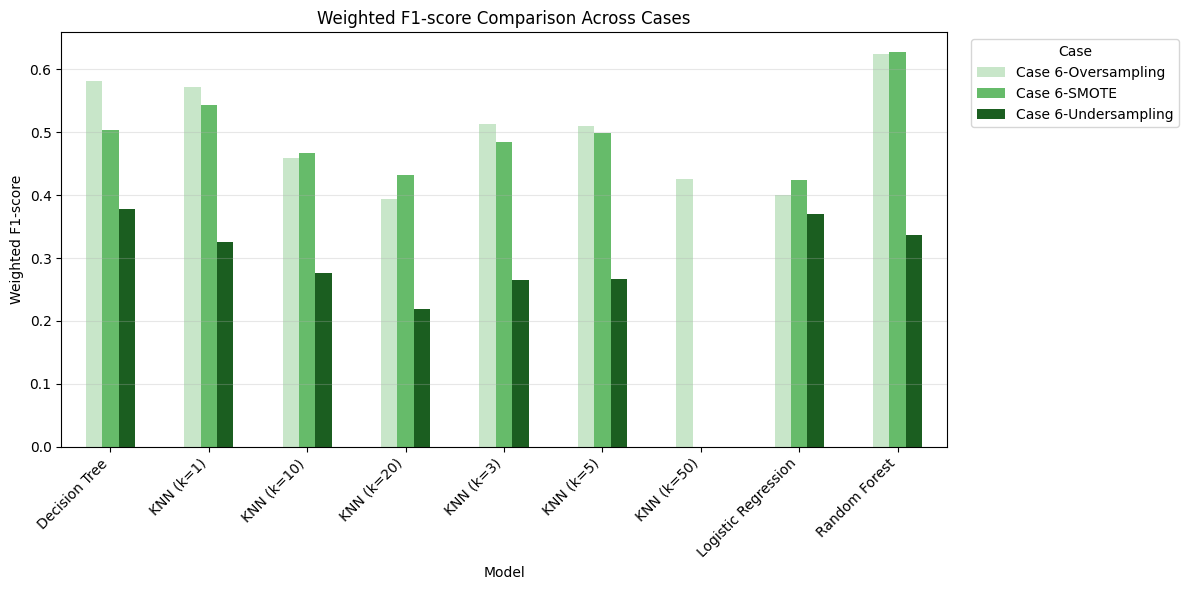

In [96]:
# F1-score Comparison
f1_table = results_all_classification.pivot(
    index="Model",
    columns="Case",
    values="F1"
)

f1_table.plot(
    kind="bar",
    figsize=(12,6),
    color=["#C8E6C9", "#66BB6A", "#1B5E20"]
)

plt.legend(
    title="Case",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.title("Weighted F1-score Comparison Across Cases")
plt.ylabel("Weighted F1-score")
plt.xlabel("Model")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

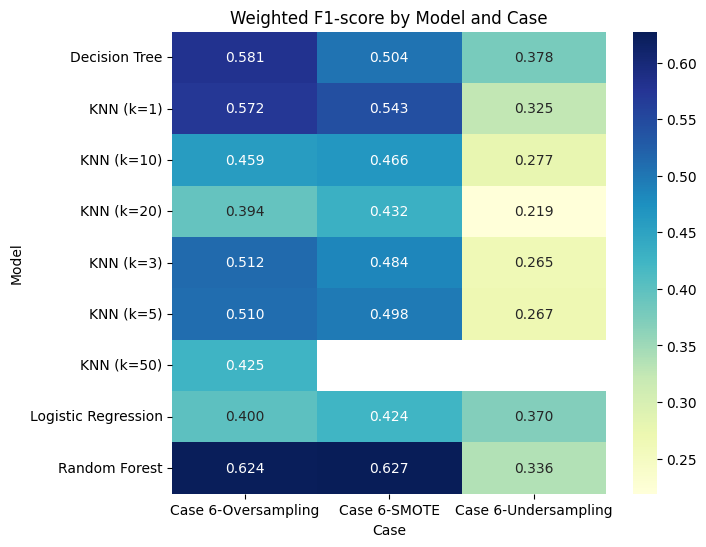

In [89]:
# Heatmap

heatmap = results_all_classification.pivot(
    index="Model",
    columns="Case",
    values="F1"
)

plt.figure(figsize=(7,6))

sns.heatmap(
    heatmap,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Weighted F1-score by Model and Case")

plt.show()

## 10. Discussion and Conclusion
Discuss which feature engineering approach and algorithm performed best, and whether categorizing pH and residual sugar improved performance.